In [9]:
import numpy as np;
import pandas as pd
import matplotlib.pyplot as plt;
from scipy.linalg import expm
from scipy.signal import find_peaks

In [4]:
def psi_exN_L(a,mu,psiin,t):
    H = np.array([[a + mu, -a/2, -a/2, 0],[-a/2, a, 0, -a/2],[-a/2, 0, a, -a/2],[0, -a/2, -a/2, a + mu]])
    NL = np.array([[2,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,0]])
    psiout = expm(1j*H*t)@psiin
    exN_L = np.real(np.vdot(psiout, NL @ psiout))
    return psiout,exN_L

In [29]:
#fourier analysis, ignore the magics...
def fourier(t_list,signal,xlim):
    dt=t_list[1]-t_list[0]
    fft_magic=np.fft.fft(signal) # could add dtype float to np array so that ensured real numbers
    freq=np.fft.fftfreq(len(signal),d=dt)
    
    #only positive frequencies
    mask=freq>0
    freq=freq[mask]
    fft_magic=fft_magic[mask]
    power=np.abs(fft_magic)**2
    
    plt.plot(freq,power,'k')
    plt.xlabel('freq')
    plt.ylabel('power of fft')
    plt.yscale('log')
    plt.xlim(xlim)
    
    #find peaks
    peaks, _ = find_peaks(power)#,height=1
    # print(peaks.shape)
    for i in range(len(peaks)):
        plt.axvline(x=freq[peaks[i]],ls='--',label=f'f={freq[peaks[i]]:.5g}')
    plt.legend()
    plt.show()
    return freq[peaks],power[peaks]

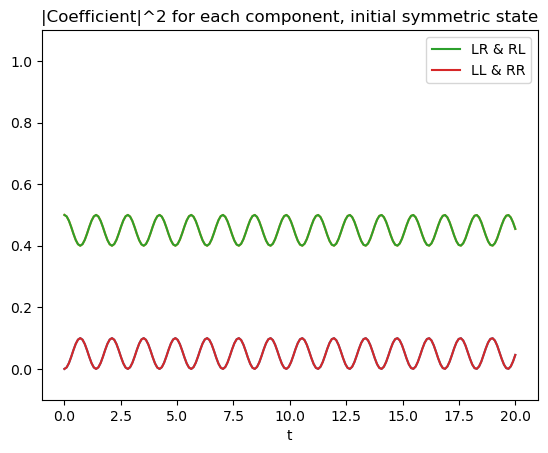

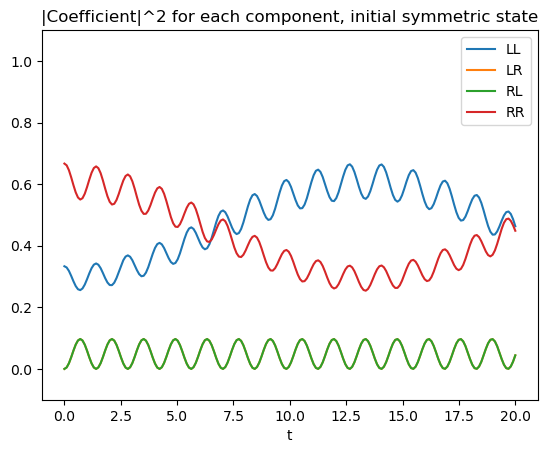

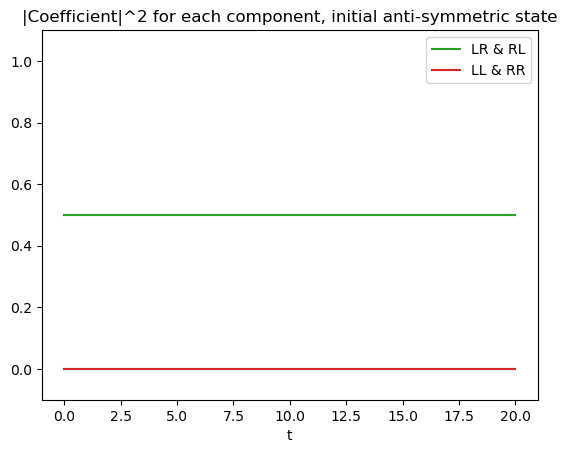

C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


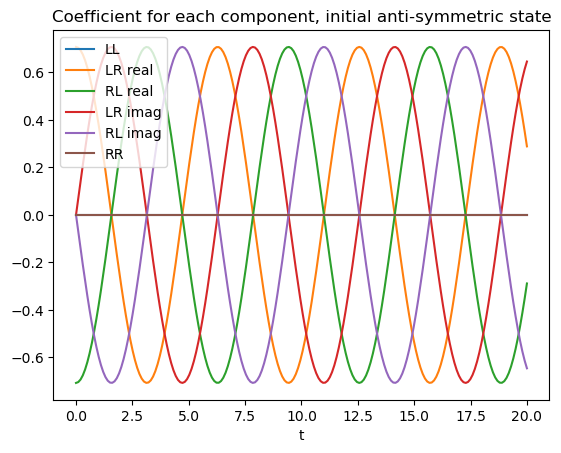

In [6]:
# checking if symmetric and antisymmetric states mix during evolution
# expect symmetric states to mix, and antisym to stay separate, due to symmetry of lagrangian, 
# and available states being either sym or antisym under swapping of the particles

a=1
mu=4

#sym state
psiin=np.array([0,1/np.sqrt(2),1/np.sqrt(2),0]) # basis LL LR RL RR
tlist=np.linspace(0,20,200)
NL_list=[]
LL=[]
LR=[]
RL=[]
RR=[]
# for i,t in enumerate(tlist):
#     (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
#     NL_list.append(exN_L)
#     LL.append(psiout[0])
#     LR.append(psiout[1])
#     RL.append(psiout[2])
#     RR.append(psiout[3])
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
    LL.append(abs(psiout[0])**2)
    LR.append(abs(psiout[1])**2)
    RL.append(abs(psiout[2])**2)
    RR.append(abs(psiout[3])**2)
# plt.plot(tlist,np.array(NL_list))
# plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
# plt.xlabel('t')
# plt.ylim(0,2)
# plt.show()

plt.plot(tlist,LL)#,label='LL')
plt.plot(tlist,LR)#,label='LR')
plt.plot(tlist,RL,label='LR & RL')
plt.plot(tlist,RR,label='LL & RR')
plt.title('|Coefficient|^2 for each component, initial symmetric state')
plt.xlabel('t')
plt.ylim(-0.1,1.1)
plt.legend()
plt.show()



#another sym state
psiin=np.array([np.sqrt(1/3),0,0,np.sqrt(2/3)]) # basis LL LR RL RR
tlist=np.linspace(0,20,200)
NL_list=[]
LL=[]
LR=[]
RL=[]
RR=[]
# for i,t in enumerate(tlist):
#     (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
#     NL_list.append(exN_L)
#     LL.append(psiout[0])
#     LR.append(psiout[1])
#     RL.append(psiout[2])
#     RR.append(psiout[3])
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
    LL.append(abs(psiout[0])**2)
    LR.append(abs(psiout[1])**2)
    RL.append(abs(psiout[2])**2)
    RR.append(abs(psiout[3])**2)
# plt.plot(tlist,np.array(NL_list))
# plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
# plt.xlabel('t')
# plt.ylim(0,2)
# plt.show()

plt.plot(tlist,LL,label='LL')
plt.plot(tlist,LR,label='LR')
plt.plot(tlist,RL,label='RL')
plt.plot(tlist,RR,label='RR')
plt.title('|Coefficient|^2 for each component, initial symmetric state')
plt.xlabel('t')
plt.ylim(-0.1,1.1)
plt.legend()
plt.show()



# antisym state
psiin=np.array([0,1/np.sqrt(2),-1/np.sqrt(2),0]) # basis LL LR RL RR
tlist=np.linspace(0,20,200)
NL_list=[]
LL=[]
LR=[]
RL=[]
RR=[]
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
    LL.append(abs(psiout[0])**2)
    LR.append(abs(psiout[1])**2)
    RL.append(abs(psiout[2])**2)
    RR.append(abs(psiout[3])**2)
# plt.plot(tlist,np.array(NL_list))
# plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
# plt.xlabel('t')
# plt.ylim(0,2)
# plt.show()
plt.plot(tlist,LL)#,label='LL') zero
plt.plot(tlist,LR)#,label='LR') 0.5
plt.plot(tlist,RL,label='LR & RL') #0.5
plt.plot(tlist,RR,label='LL & RR') #zero
plt.title('|Coefficient|^2 for each component, initial anti-symmetric state')
plt.xlabel('t')
plt.ylim(-0.1,1.1)
plt.legend()
plt.show()


# antisym state, coeffs, not |coeffs|^2
# shows that stay in LR-RL but change global phase, ie move from real to imag parts, but LR always has opposite sign to RL
psiin=np.array([0,1/np.sqrt(2),-1/np.sqrt(2),0]) # basis LL LR RL RR
tlist=np.linspace(0,20,200)
NL_list=[]
LL=[]
LR=[]
RL=[]
RR=[]
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
    LL.append(psiout[0])
    LR.append(psiout[1])
    RL.append(psiout[2])
    RR.append(psiout[3])
# plt.plot(tlist,np.array(NL_list))
# plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
# plt.xlabel('t')
# plt.ylim(0,2)
# plt.show()
LR=np.array(LR)
RL=np.array(RL)
plt.plot(tlist,LL,label='LL') #zero
plt.plot(tlist,LR.real,label='LR real') #0.5
plt.plot(tlist,RL.real,label='RL real') #0.5
plt.plot(tlist,LR.imag,label='LR imag') #0.5
plt.plot(tlist,RL.imag,label='RL imag') #0.5
plt.plot(tlist,RR,label='RR') #zero
plt.title('Coefficient for each component, initial anti-symmetric state')
plt.xlabel('t')
# plt.ylim(-0.1,1.1)
plt.legend()
plt.show()

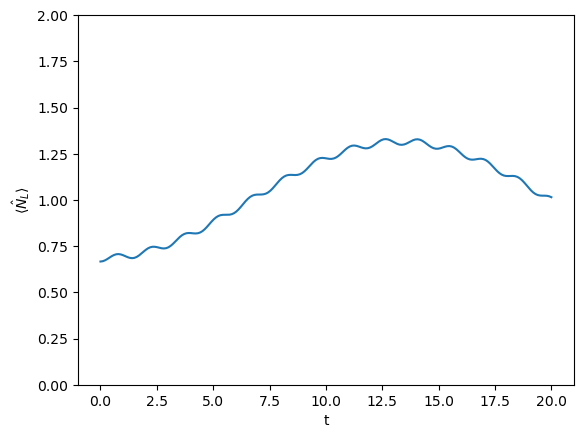

In [7]:
# evolution from number of particles in the left well
a=1
mu=4
psiin=np.array([np.sqrt(1/3),0,0,np.sqrt(2/3)]) # basis LL LR RL RR
tlist=np.linspace(0,20,200)
NL_list=[]
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
# print(NL_list)
plt.plot(tlist,NL_list)
plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
plt.xlabel('t')
plt.ylim(0,2)
plt.show()

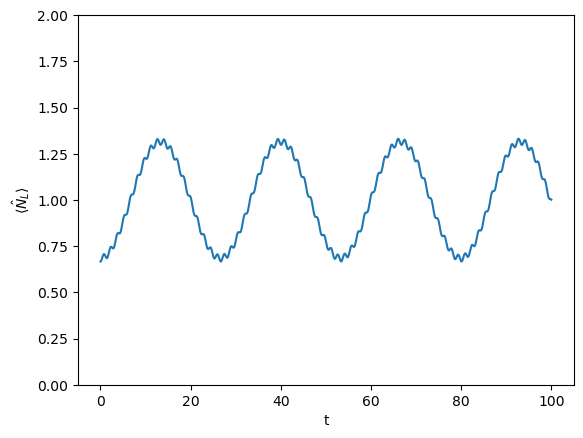

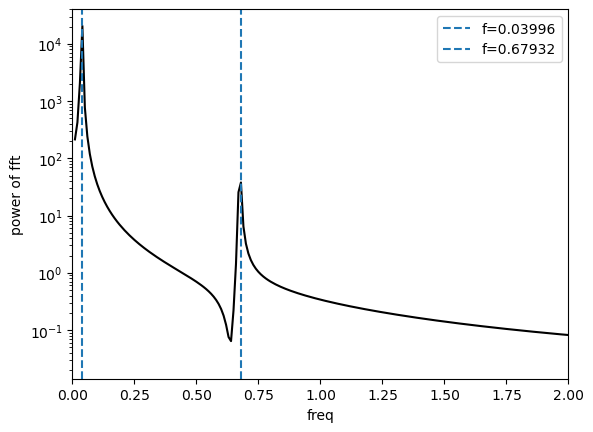

(array([0.03996, 0.67932]), array([20539.92486117,    37.75402096]))

In [34]:
# evolution from number of particles in the left well
a=1
mu=4
psiin=np.array([np.sqrt(1/3),0,0,np.sqrt(2/3)]) # basis LL LR RL RR
tlist=np.linspace(0,100,1000)
NL_list=[]
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
# print(NL_list)
plt.plot(tlist,NL_list)
plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
plt.xlabel('t')
plt.ylim(0,2)
plt.show()

signal=NL_list
fourier(tlist,signal,[0,2])

In [32]:
# find e'vals of hamiltonian, energy differences of these evals should correspond to frequencies of the evolution
# see that the two frequencies in the evolution (if start in 1/3 LL and 2/3 RR ) are similar to the two repeated
# frequencies from the evals
a=1
mu=4
H = np.array([[a+mu,-a/2,-a/2,0],
                  [-a/2,a,0,-a/2],
                  [-a/2,0,a,-a/2],
                  [0,-a/2,-a/2,a+mu]])


evals, evecs = np.linalg.eigh(H)
print(evals)
# print(evecs)

delE=[]
for i in range(len(evals)):
    for j in range(i+1,len(evals)):
        dE=evals[j]-evals[i]
        delE.append(dE)
delE=np.array(delE)
# print(delE)
print(delE/(2*np.pi)) # these should potentially match up with the evolution frequency?
# E=hf f=E/2pihbar 

# print(evecs[0][0]**2+evecs[0][1]**2+evecs[0][2]**2+evecs[0][3]**2)

[0.76393202 1.         5.         5.23606798]
[0.03757139 0.67419116 0.71176254 0.63661977 0.67419116 0.03757139]


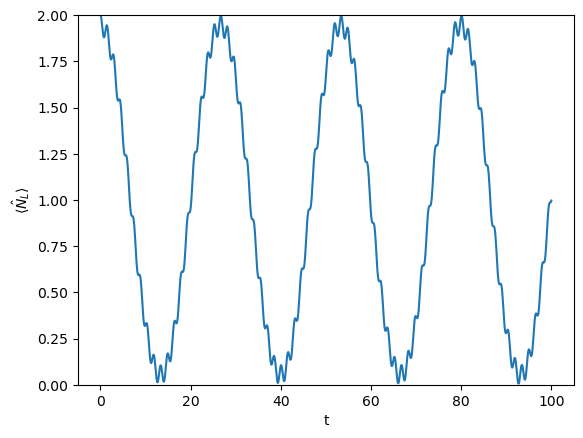

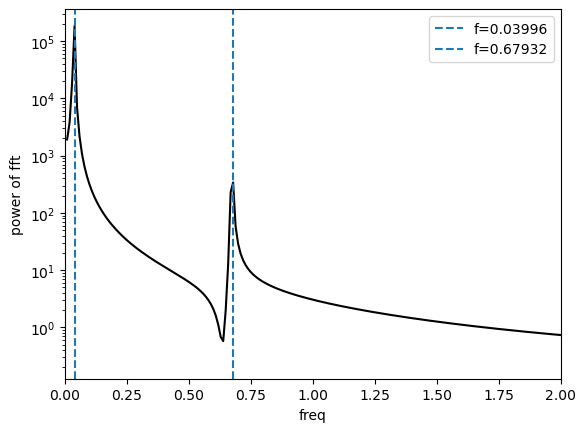

(array([0.03996, 0.67932]), array([184859.32375055,    339.78618863]))

In [35]:
# evolution from number of particles in the left well
a=1
mu=4
psiin=np.array([1,0,0,0]) # basis LL LR RL RR
tlist=np.linspace(0,100,1000)
NL_list=[]
for i,t in enumerate(tlist):
    (psiout,exN_L)=psi_exN_L(a,mu,psiin,t)
    NL_list.append(exN_L)
# print(NL_list)
plt.plot(tlist,NL_list)
plt.ylabel(rf'$\langle \hat{{N}}_L \rangle$')
plt.xlabel('t')
plt.ylim(0,2)
plt.show()

signal=NL_list
fourier(tlist,signal,[0,2])